In [1]:
#Install Libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install wordcloud
!pip install spacy
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.76.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.18.0-cp313-cp313-win_amd64.whl.metadata (35 kB)
Using cached ten

In [2]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import wordcloud
import re
import spacy
import tensorflow as tf

C:\Users\User\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
#Define Dataset
df = pd.read_csv('Reviews.csv')

In [4]:
#Print Dataset Information,Sample Size and Number of variables (Shape)
print("Dataset Information")
print(f"Sample Size: {df.shape[0]} customers")
print(f"Number of variables: {df.shape[1]}")
df.info()

Dataset Information
Sample Size: 568454 customers
Number of variables: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [5]:
#Show the first 5 rows
print("Initial Data Sample")
print(df.head(5))

Initial Data Sample
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vital

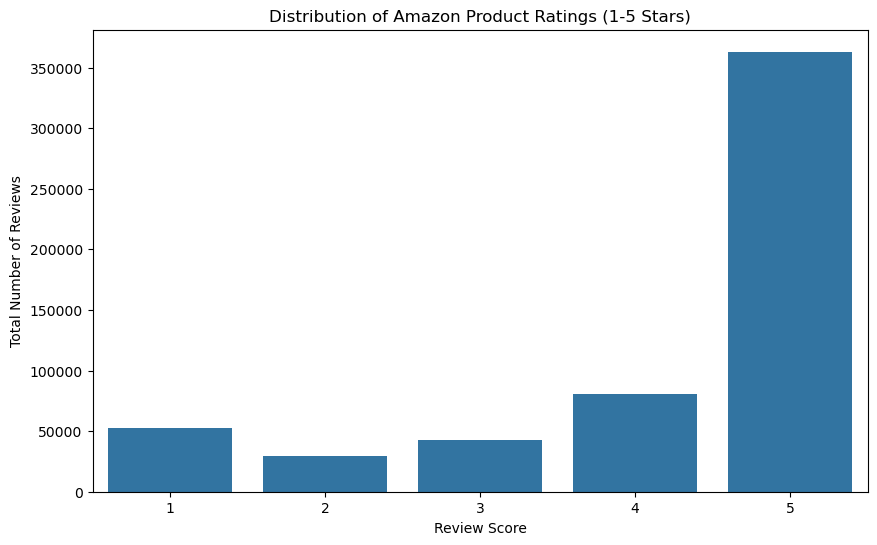

In [6]:
# Graph 1: Star Ratings
plt.figure(figsize=(10, 6))
sns.countplot(x='Score', data=df,)
plt.title('Distribution of Amazon Product Ratings (1-5 Stars)')
plt.xlabel('Review Score')
plt.ylabel('Total Number of Reviews')
plt.show()

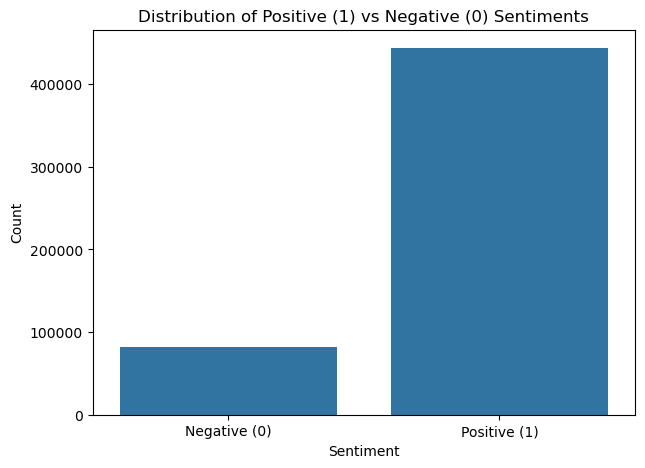

In [7]:
# Transformation score into categories (Sentiment)
df_filtered = df[df['Score'] != 3].copy()
df_filtered['Sentiment'] = df_filtered['Score'].apply(lambda x: 1 if x > 3 else 0)

# Graph 2: Star Ratings categories
plt.figure(figsize=(7, 5))
sns.countplot(x='Sentiment', data=df_filtered)
plt.title('Distribution of Positive (1) vs Negative (0) Sentiments')
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.ylabel('Count')
plt.show()

In [8]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Download the necessary packages from NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


def preprocess_text(text):
    # Data Cleaning
    # Use Regex to remove any non-letter, Transform to lowercase 
    text = re.sub(r'[^a-zA-Z]', ' ', str(text).lower())
    
    # Tokenization
    words = text.split()
    
    # Stop-words Removal and Lemmatization
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply Data Cleaning
df_sample = df_filtered.sample(5000, random_state=42)
df_sample['Cleaned_Text'] = df_sample['Text'].apply(preprocess_text)

# Display the result for comparison
print(df_sample[['Text', 'Cleaned_Text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                                     Text  \
443593  This is a very high quality dog food with meat...   
136949  I love this cake mix and the other 3 mixes as ...   
520459  A nice strong brew. I am new to Keurig and hav...   
219515  I just found PB2 and PB2 with chocolate and I ...   
471273  Delightful mint tea as one would expect. Note ...   

                                             Cleaned_Text  
443593  high quality dog food meat fruit grain dog lov...  
136949  love cake mix mix well incredible amazon offer...  
520459  nice strong brew new keurig lived french press...  
219515  found pb pb chocolate thrilled love sugary goo...  
471273  delightful mint tea one would expect note tea ...  


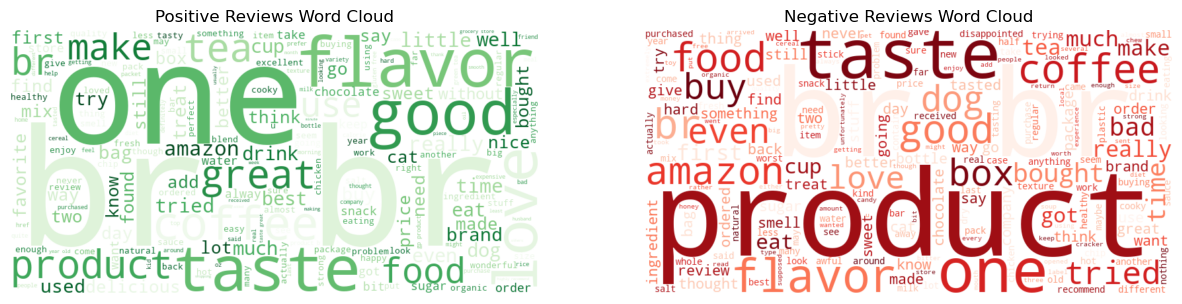

In [9]:
from wordcloud import WordCloud

# Separate the positive and negative texts
positive_text = " ".join(df_sample[df_sample['Sentiment'] == 1]['Cleaned_Text'])
negative_text = " ".join(df_sample[df_sample['Sentiment'] == 0]['Cleaned_Text'])

# Creating a cloud of positive words
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

# Creating a cloud of negative words
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# WordCloud
plt.figure(figsize=(15, 7))

# Show Positive Words
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

# Show Negative Words
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')

plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert raw text to array
tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df_sample['Cleaned_Text']).toarray()
y = df_sample['Sentiment']

print(f"\nShape of X (Features): {X.shape}")


Shape of X (Features): (5000, 2500)


In [11]:
!python -m spacy download en_core_web_sm
# Download the English version of the model
nlp = spacy.load("en_core_web_sm")

# Applying the processes to a sample from a single review for illustration
sample_text = "Amazon provided a great phone, but the delivery by FedEx was late."
doc = nlp(sample_text)

# Implementing POS Tagging
print("POS Tagging")
for token in doc:
    print(f"{token.text} --> {token.pos_}")

# NER Implementation
print("\nNamed Entity Recognition (NER)")
for ent in doc.ents:
    print(f"Entity: {ent.text}, Label: {ent.label_}")

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.2 MB/s eta 0:00:11
     - -------------------------------------- 0.5/12.8 MB 1.2 MB/s eta 0:00:11
     -- ------------------------------------- 0.8/12.8 MB 1.1 MB/s eta 0:00:11
     --- ------------------------------------ 1.0/12.8 MB 1.1 MB/s eta 0:00:11
     ---- ----------------------------------- 1.3/12.8 MB 1.1 MB/s eta 0:00:11
     ---- ----------------------------------- 1.3/12.8 MB 1.1 MB/s eta 0:00:11
     ---- ---------------------------------- 1.6/12.8 MB 960.9 kB/s eta 0:00:12
     ----- --------------------------------- 1.8/12.8 MB 973.5 kB/s eta 0:00:12
     ----- --------------------------------- 1.8/12.8 MB 973.5 kB/s eta 0:00:12
     ------ -------------------------------- 2.1/12.8 MB 954.2 kB/s eta 0:00:12
     ------- ------------------------------- 2.4/12.8 MB 937.0

In [12]:
# Word Embeddings
print("\n Word Embeddings (Vector representation")
first_token = doc[0] 
print(f"Word: {first_token.text}")
print(f"Vector (First 10 values): {first_token.vector[:10]}")
print(f"Vector Shape: {first_token.vector.shape}")


 Word Embeddings (Vector representation
Word: Amazon
Vector (First 10 values): [-1.4584436  -0.4298126   0.7456652   0.22648771  0.5593522   0.50314885
  1.5457511   0.81502676 -0.9093803  -0.02859047]
Vector Shape: (96,)


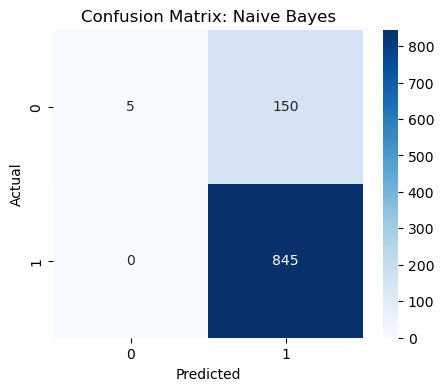

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Naive data segmentation (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Confusion Matrix (Comparison Graph)
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_cm(y_test, y_pred_nb, 'Confusion Matrix: Naive Bayes')

In [19]:
from sklearn.metrics import accuracy_score

# Evaluating the accuracy of the Naive Bayes model
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"MNB Model Accuracy: {nb_accuracy*100:.2f}%")

MNB Model Accuracy: 85.00%


In [21]:
# Extracting the detailed report (Precision, Recall, F1)
print("\n MNB Detailed Performance Report")
print(classification_report(y_test, y_pred_nb))


 MNB Detailed Performance Report
              precision    recall  f1-score   support

           0       1.00      0.03      0.06       155
           1       0.85      1.00      0.92       845

    accuracy                           0.85      1000
   macro avg       0.92      0.52      0.49      1000
weighted avg       0.87      0.85      0.79      1000



Starting LSTM Training...
Epoch 1/3


C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8461 - loss: 0.4263 - val_accuracy: 0.8625 - val_loss: 0.3432
Epoch 2/3
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9017 - loss: 0.2521 - val_accuracy: 0.9025 - val_loss: 0.2539
Epoch 3/3
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9561 - loss: 0.1256 - val_accuracy: 0.8975 - val_loss: 0.2544
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step  


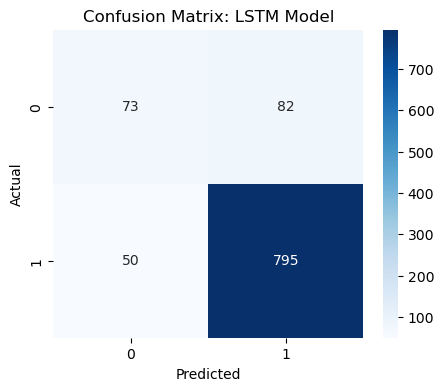

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# LSTM Model Preprocessing
max_words = 5000 
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_sample['Cleaned_Text'])
sequences = tokenizer.texts_to_sequences(df_sample['Cleaned_Text'])
X_lstm = pad_sequences(sequences, maxlen=max_len)

# LSTM data segmentation (80% training, 20% testing)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lstm, y, test_size=0.2, random_state=42)

# LSTM Architecture Planning
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# LSTM Model Training
print("Starting LSTM Training...")
history = model.fit(X_train_l, y_train_l, epochs=3, batch_size=32, validation_split=0.1)

# LSTM Model Evaluation
y_pred_lstm = (model.predict(X_test_l) > 0.5).astype("int32")
plot_cm(y_test_l, y_pred_lstm, 'Confusion Matrix: LSTM Model') 


In [23]:
# Evaluating the accuracy of the model on test data
scores = model.evaluate(X_test_l, y_test_l, verbose=0)
print(f"LSTM Model Accuracy: {scores[1]*100:.2f}%")

LSTM Model Accuracy: 86.80%


In [25]:
from sklearn.metrics import classification_report

# Converting predictions from decimal numbers to (0 or 1)
y_pred_lstm = (model.predict(X_test_l) > 0.5).astype("int32")

# View Classification Report
print("LSTM Classification Report")
print(classification_report(y_test_l, y_pred_lstm))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
LSTM Classification Report
              precision    recall  f1-score   support

           0       0.59      0.47      0.53       155
           1       0.91      0.94      0.92       845

    accuracy                           0.87      1000
   macro avg       0.75      0.71      0.72      1000
weighted avg       0.86      0.87      0.86      1000



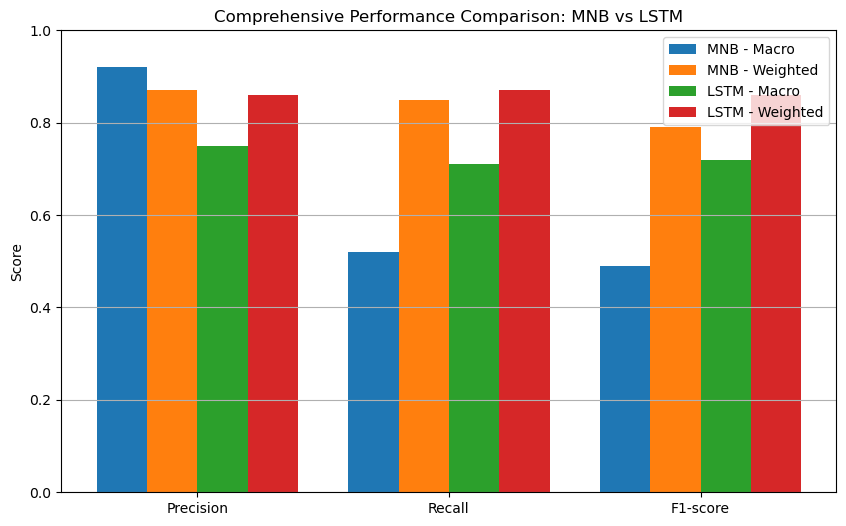

In [27]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ['Precision', 'Recall', 'F1-score']

mnb_macro = [0.92, 0.52, 0.49]
mnb_weighted = [0.87, 0.85, 0.79]
lstm_macro = [0.75, 0.71, 0.72]
lstm_weighted = [0.86, 0.87, 0.86]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, mnb_macro, width, label='MNB - Macro')
plt.bar(x - 0.5*width, mnb_weighted, width, label='MNB - Weighted')
plt.bar(x + 0.5*width, lstm_macro, width, label='LSTM - Macro')
plt.bar(x + 1.5*width, lstm_weighted, width, label='LSTM - Weighted')

plt.ylabel('Score')
plt.title('Comprehensive Performance Comparison: MNB vs LSTM')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')

plt.show()
